# 03. Моделирование и оптимизация

**Вход:** `clustered.csv`  
**Выход:** `models_gmm.pkl`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error
import pickle
import warnings, gc
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

## Настраиваемые параметры

In [2]:
INPUT_FILE = 'clustered.csv'
FEATURES = ['pressure_axis', 'pressure_rotation']
TARGET = 'speed'
N_SPLITS = 5
RANDOM_STATE = 21
COLORS = ['#22c55e','#84cc16','#eab308','#f59e0b','#ef4444','#dc2626','#7c3aed','#0ea5e9']

## 1. Загрузка

In [3]:
df = pd.read_csv(INPUT_FILE)
N_CLUSTERS = df['cluster'].nunique()
gkf = GroupKFold(n_splits=N_SPLITS)
print(f'{len(df)} строк, {df["well_id"].nunique()} скважин, {N_CLUSTERS} кластеров')

427200 строк, 1735 скважин, 7 кластеров


## 2. Обучение, валидация и оптимизация

Один проход: для каждого кластера —  
1. CV скоры (GroupKFold по well_id)  
2. Обучение GBM на всех данных  
3. Grid max (P_ос, P_вр) → max v  
4. Best operators (топ 25% скорости из реальных данных)

In [ ]:
final_models = {}
opt_results = []
cv_scores = {}
gkf = GroupKFold(n_splits=N_SPLITS)

for c in range(N_CLUSTERS):
    sub = df[df['cluster']==c]
    X, y = sub[FEATURES].values, sub[TARGET].values
    groups = sub['well_id'].values
    
    gbm = GradientBoostingRegressor(
        n_estimators=150, max_depth=4, learning_rate=0.05,
        subsample=0.8, random_state=RANDOM_STATE
    )
    
    scores = cross_val_score(gbm, X, y, cv=gkf, groups=groups, scoring='r2')
    cv_scores[c] = scores.mean()
    
    gbm.fit(X, y)
    fi = gbm.feature_importances_
    
    pa_lo = sub['pressure_axis'].quantile(0.05)
    pa_hi = sub['pressure_axis'].quantile(0.95)
    pr_lo = sub['pressure_rotation'].quantile(0.05)
    pr_hi = sub['pressure_rotation'].quantile(0.95)
    
    PA, PR = np.meshgrid(np.linspace(pa_lo, pa_hi, 40), np.linspace(pr_lo, pr_hi, 40))
    v_grid = gbm.predict(np.column_stack([PA.ravel(), PR.ravel()]))
    best = np.argmax(v_grid)
    grid_v = v_grid[best]
    grid_pa, grid_pr = PA.ravel()[best], PR.ravel()[best]
    grid_gain = (grid_v - y.mean()) / y.mean() * 100
    
    q75 = sub['speed'].quantile(0.75)
    top25 = sub[sub['speed'] >= q75]
    best_v = top25['speed'].mean()
    best_pa = top25['pressure_axis'].median()
    best_pr = top25['pressure_rotation'].median()
    best_gain = (best_v - y.mean()) / y.mean() * 100
    
    final_models[c] = gbm
    opt_results.append({
        'cluster': c, 'R2_cv': cv_scores[c], 'R2_std': scores.std(),
        'fi_Pax': fi[0], 'fi_Prot': fi[1],
        'current_v': y.mean(), 'n_records': len(sub), 'n_wells': sub['well_id'].nunique(),
        'current_Pax': sub['pressure_axis'].median(),
        'current_Prot': sub['pressure_rotation'].median(),
        'grid_v': grid_v, 'grid_gain': grid_gain,
        'grid_Pax': grid_pa, 'grid_Prot': grid_pr,
        'best_v': best_v, 'best_gain': best_gain,
        'best_Pax': best_pa, 'best_Prot': best_pr, 'best_n': len(top25),
    })
    del gbm; gc.collect()

summary = pd.DataFrame([{
    'Кластер': r['cluster'],
    'Записей': r['n_records'],
    'Скважин': r['n_wells'],
    'R² mean': round(r['R2_cv'], 4),
    'R² std': round(r['R2_std'], 4),
    'FI P_вр': f"{r['fi_Prot']:.0%}",
} for r in opt_results]).set_index('Кластер')

summary

,Записей,Скважин,R² mean,R² std,FI P_вр
Кластер,,,,,
0,12772,1474,0.4108,0.0635,73%
1,30522,1636,0.7312,0.0078,68%
2,66351,1715,0.7853,0.0070,82%
3,124006,1718,0.7611,0.0115,90%
4,117369,1664,0.7218,0.0160,88%
5,69910,1555,0.3134,0.0750,76%
6,6270,892,0.2642,0.0493,62%


## 3. Сравнение подходов и рекомендации

**Grid max** — модель предсказывает максимум на сетке (всегда в углу).  
**Best operators** — реальные давления у записей с наибольшей скоростью (верхний квартиль).

In [ ]:
compare_df = pd.DataFrame([{
    'Кластер': int(r['cluster']),
    'Записей': r['n_records'],
    'R²': round(r['R2_cv'], 3),
    'v текущая': round(r['current_v'], 5),
    'v grid max': round(r['grid_v'], 5),
    'grid gain': f"+{r['grid_gain']:.0f}%",
    'v best 25%': round(r['best_v'], 5),
    'best gain': f"+{r['best_gain']:.0f}%",
} for r in opt_results]).set_index('Кластер')

compare_df

,Записей,R²,v текущая,v grid max,grid gain,v best 25%,best gain
Кластер,,,,,,,
0,12772,0.411,0.02780,0.06314,+127%,0.05848,+110%
1,30522,0.731,0.01850,0.03928,+112%,0.03184,+72%
2,66351,0.785,0.01828,0.03004,+64%,0.02718,+49%
3,124006,0.761,0.01554,0.02114,+36%,0.02079,+34%
4,117369,0.722,0.01098,0.01530,+39%,0.01379,+26%
5,69910,0.313,0.00601,0.00860,+43%,0.00698,+16%
6,6270,0.264,0.00707,0.01589,+125%,0.01574,+122%


In [ ]:
rec_df = pd.DataFrame([{
    'Кластер': int(r['cluster']),
    'R²': round(r['R2_cv'], 3),
    'FI P_вр': f"{r['fi_Prot']:.0%}",
    'v текущая': round(r['current_v'], 5),
    'v рекомендация': round(r['best_v'], 5),
    'Прирост': f"+{r['best_gain']:.1f}%",
    'P_ос текущее': f"{r['current_Pax']:.0f}",
    'P_ос рекомендация': f"{r['best_Pax']:.0f}",
    'P_вр текущее': f"{r['current_Prot']:.0f}",
    'P_вр рекомендация': f"{r['best_Prot']:.0f}",
} for r in opt_results]).set_index('Кластер')

rec_df

,R²,FI P_вр,v текущая,v рекомендация,Прирост,P_ос текущее,P_ос рекомендация,P_вр текущее,P_вр рекомендация
Кластер,,,,,,,,,
0,0.411,73%,0.02780,0.05848,+110.3%,4641,6529,7641,9872
1,0.731,68%,0.01850,0.03184,+72.1%,8915,13234,9566,11431
2,0.785,82%,0.01828,0.02718,+48.7%,15941,18467,12825,15696
3,0.761,90%,0.01554,0.02079,+33.8%,19264,20660,15333,17081
4,0.722,88%,0.01098,0.01379,+25.6%,20402,21086,15637,16714
5,0.313,76%,0.00601,0.00698,+16.2%,20155,20655,14668,15226
6,0.264,62%,0.00707,0.01574,+122.5%,18939,19762,14256,16214


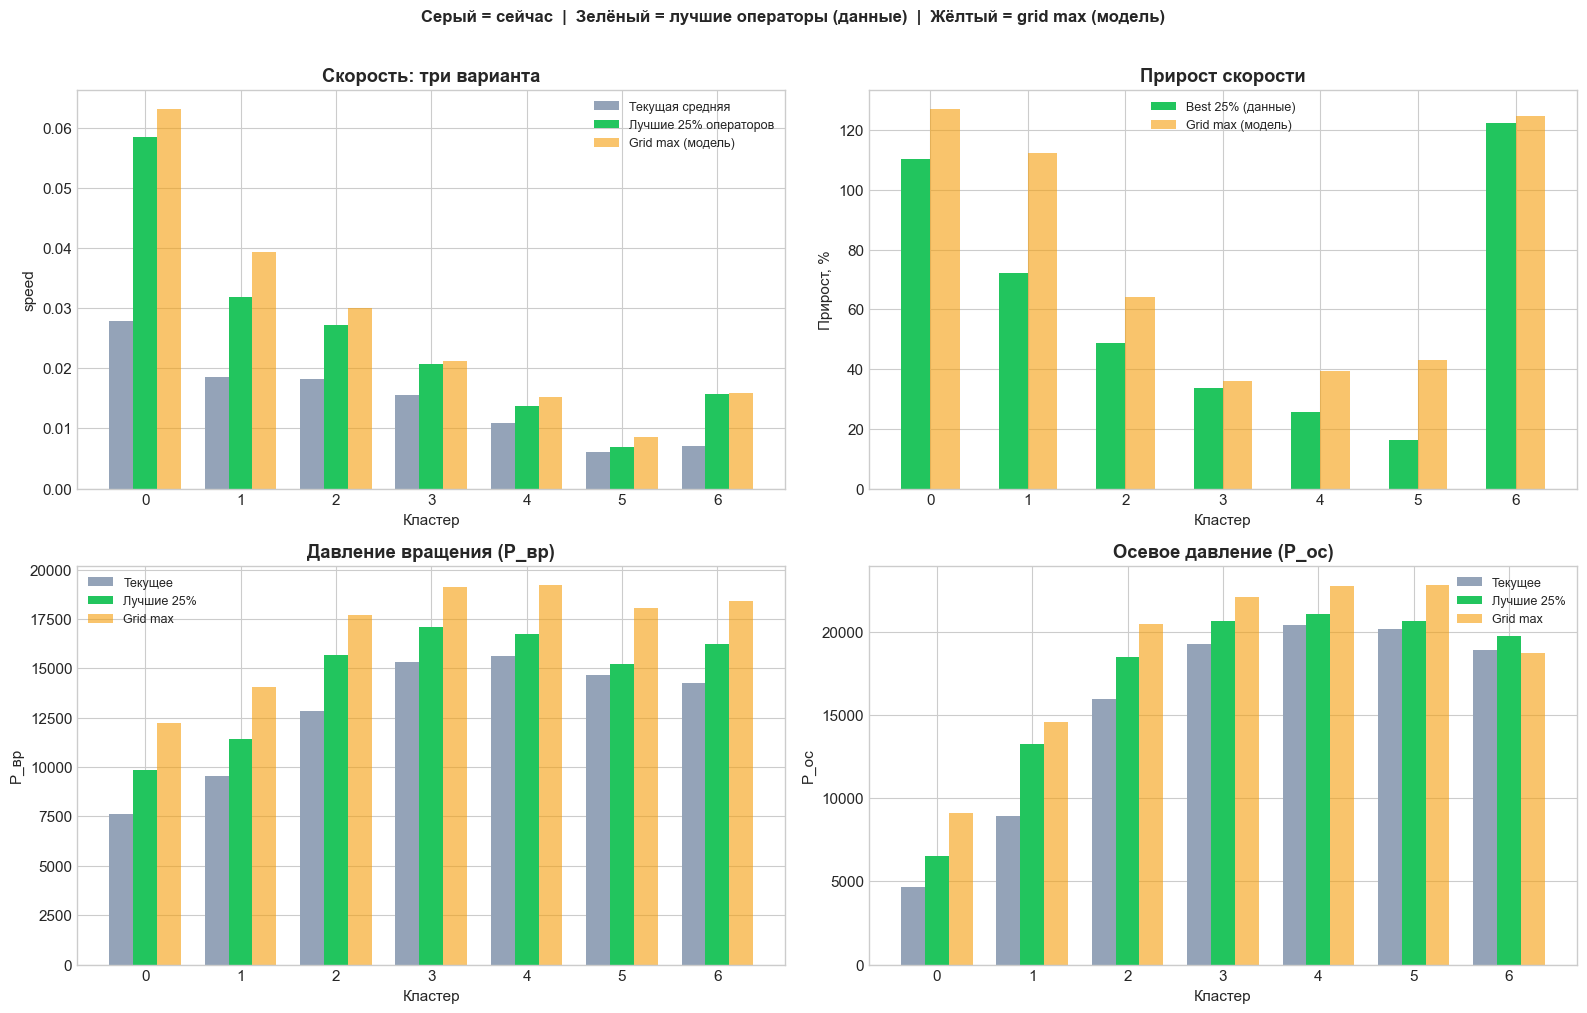

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
x = np.arange(N_CLUSTERS)
w = 0.25

ax = axes[0, 0]
cur_v = [r['current_v'] for r in opt_results]
best_v = [r['best_v'] for r in opt_results]
grid_v = [r['grid_v'] for r in opt_results]
ax.bar(x - w, cur_v, w, label='Текущая средняя', color='#94a3b8')
ax.bar(x, best_v, w, label='Лучшие 25% операторов', color='#22c55e')
ax.bar(x + w, grid_v, w, label='Grid max (модель)', color='#f59e0b', alpha=0.6)
ax.set_xlabel('Кластер'); ax.set_ylabel('speed')
ax.set_title('Скорость: три варианта', fontweight='bold')
ax.set_xticks(x); ax.legend(fontsize=9)

ax = axes[0, 1]
best_g = [r['best_gain'] for r in opt_results]
grid_g = [r['grid_gain'] for r in opt_results]
ax.bar(x - 0.15, best_g, 0.3, label='Best 25% (данные)', color='#22c55e')
ax.bar(x + 0.15, grid_g, 0.3, label='Grid max (модель)', color='#f59e0b', alpha=0.6)
ax.set_xlabel('Кластер'); ax.set_ylabel('Прирост, %')
ax.set_title('Прирост скорости', fontweight='bold')
ax.set_xticks(x); ax.legend(fontsize=9)

ax = axes[1, 0]
cur_pr = [r['current_Prot'] for r in opt_results]
best_pr = [r['best_Prot'] for r in opt_results]
grid_pr = [r['grid_Prot'] for r in opt_results]
ax.bar(x - w, cur_pr, w, label='Текущее', color='#94a3b8')
ax.bar(x, best_pr, w, label='Лучшие 25%', color='#22c55e')
ax.bar(x + w, grid_pr, w, label='Grid max', color='#f59e0b', alpha=0.6)
ax.set_xlabel('Кластер'); ax.set_ylabel('P_вр')
ax.set_title('Давление вращения (P_вр)', fontweight='bold')
ax.set_xticks(x); ax.legend(fontsize=9)

ax = axes[1, 1]
cur_pa = [r['current_Pax'] for r in opt_results]
best_pa = [r['best_Pax'] for r in opt_results]
grid_pa = [r['grid_Pax'] for r in opt_results]
ax.bar(x - w, cur_pa, w, label='Текущее', color='#94a3b8')
ax.bar(x, best_pa, w, label='Лучшие 25%', color='#22c55e')
ax.bar(x + w, grid_pa, w, label='Grid max', color='#f59e0b', alpha=0.6)
ax.set_xlabel('Кластер'); ax.set_ylabel('P_ос')
ax.set_title('Осевое давление (P_ос)', fontweight='bold')
ax.set_xticks(x); ax.legend(fontsize=9)

plt.suptitle('Серый = сейчас  |  Зелёный = лучшие операторы (данные)  |  Жёлтый = grid max (модель)', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 4. Feature Importance

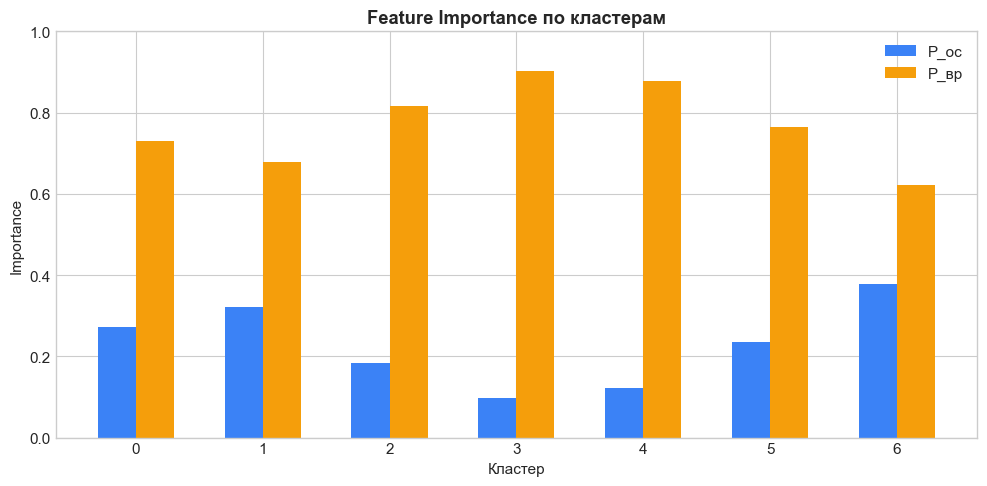

,P_ос,P_вр
Кластер,,
0,0.271,0.729
1,0.322,0.678
2,0.184,0.816
3,0.098,0.902
4,0.123,0.877
5,0.235,0.765
6,0.379,0.621


In [8]:
fi_df = pd.DataFrame([{
    'Кластер': c,
    'P_ос': round(final_models[c].feature_importances_[0], 3),
    'P_вр': round(final_models[c].feature_importances_[1], 3),
} for c in range(N_CLUSTERS)]).set_index('Кластер')

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(N_CLUSTERS)
ax.bar(x-0.15, fi_df['P_ос'], 0.3, label='P_ос', color='#3b82f6')
ax.bar(x+0.15, fi_df['P_вр'], 0.3, label='P_вр', color='#f59e0b')
ax.set_xlabel('Кластер'); ax.set_ylabel('Importance')
ax.set_title('Feature Importance по кластерам', fontweight='bold')
ax.set_xticks(x); ax.legend(); ax.set_ylim(0, 1)
plt.tight_layout(); plt.show()

fi_df

## 5. Функция онлайн-рекомендации

In [9]:
gm_final = GaussianMixture(n_components=N_CLUSTERS, random_state=RANDOM_STATE, n_init=5)
gm_final.fit(df[['log_EI']].values)
cluster_remap = {old: new for new, old in enumerate(
    df.groupby('cluster')['log_EI'].mean().sort_values().index.tolist())}

def recommend(ei_value):
    log_ei = np.log10(ei_value)
    probs = gm_final.predict_proba([[log_ei]])[0]
    raw = probs.argmax()
    c = cluster_remap.get(raw, raw)
    conf = probs[raw]
    o = opt_results[c]
    return {'cluster': c, 'confidence': round(conf, 3),
            'P_ос рек.': round(o['best_Pax']),
            'P_вр рек.': round(o['best_Prot']),
            'v ожидаемая': round(o['best_v'], 5),
            'R²': round(o['R2_cv'], 3)}

examples = [recommend(ei) for ei in [5e10, 5e11, 2e12, 5e12, 1e13]]
pd.DataFrame(examples)

,cluster,confidence,P_ос рек.,P_вр рек.,v ожидаемая,R²
0,3,1.000,20660,17081,0.02079,0.761
1,1,0.890,13234,11431,0.03184,0.731
2,2,0.871,18467,15696,0.02718,0.785
3,0,0.961,6529,9872,0.05848,0.411
4,6,0.740,19762,16214,0.01574,0.264


## 6. Сохранение

In [1]:
opt_save = [{k: v for k, v in r.items() if not isinstance(v, tuple)} for r in opt_results]

save_data = {
    'models': final_models, 'gmm': gm_final, 'cluster_remap': cluster_remap,
    'optimization': opt_save, 'cv_scores': cv_scores,
    'features': FEATURES, 'n_clusters': N_CLUSTERS,
}
with open('models_gmm.pkl', 'wb') as f:
    pickle.dump(save_data, f)
print(f'Сохранено: models_gmm.pkl ({N_CLUSTERS} моделей)')

NameError: name 'opt_results' is not defined